# ICT-4204: Mobile and Cellular Communication Laboratory
## Complete Laboratory Manual & Experiment Codebook (Experiments 01 – 09)

**Course Title:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Academic Session:** 4th Year 2nd Semester  
**Department:** Department of Information and Communication Technology  
**Institution:** Islamic University, Kushtia-7003, Bangladesh  
**Platform:** Python 3 / Jupyter Notebook (NumPy, Matplotlib, Pandas)

---

### Table of Contents

1. [Experiment 01: Calculation of Doppler Shift and Maximum Mobile Velocity](#exp01)
2. [Experiment 02: Calculation of Co-channel Reuse Distance and Reuse Ratio](#exp02)
3. [Experiment 03: Study of Frequency Allocation and Channel Assignment in Cellular Networks](#exp03)
4. [Experiment 04: Study and Simulation of GSM Network Architecture](#exp04)
5. [Experiment 05: Simulation of Handover Between Two Cellular Cells](#exp05)
6. [Experiment 06: Received Signal Strength-Based Base Station Selection](#exp06)
7. [Experiment 07: Free-Space Path Loss and Received Power Analysis](#exp07)
8. [Experiment 08: Analysis of Cell Coverage, Cell Radius, and Cell Splitting](#exp08)
9. [Experiment 09: Cellular Traffic, Channel Capacity, and Erlang-B Blocking Probability Analysis](#exp09)

---


<a id="exp01"></a>

# Experiment 01: Calculation of Doppler Shift and Maximum Mobile Velocity

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** ICT-4204 Practical Experiment Assignment; previous-year Doppler question; William C. Y. Lee reference text for mobile-channel context.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To calculate Doppler shift for a moving mobile terminal and to determine the maximum mobile velocity for a specified maximum Doppler frequency.

## Objectives

- Understand why relative motion changes the received carrier frequency.
- Relate carrier frequency, wavelength, velocity, and direction of motion.
- Calculate maximum Doppler shift.
- Recover mobile velocity from a measured maximum Doppler shift.
- Visualize how Doppler shift varies with angle and mobile speed.

## Theory

When a mobile terminal moves relative to the direction of arrival of a radio wave, the received carrier is shifted in frequency. This is the **Doppler effect**. Motion **toward** the arriving wave produces a positive shift, while motion **away** produces a negative shift.

The wavelength of a carrier is

$$
\lambda = \frac{c}{f_c}
$$

where:

- $c \approx 3\times 10^8$ m/s is the speed of light,
- $f_c$ is the carrier frequency in hertz,
- $\lambda$ is the wavelength in metres.

For a mobile moving with speed $v$, the Doppler shift of one arriving path is modeled by

$$
f_d = \frac{v}{\lambda}\cos\theta
$$

or, after substituting $\lambda=c/f_c$,

$$
f_d = \frac{v f_c}{c}\cos\theta
$$

where $\theta$ is the angle between the mobile velocity vector and the direction of arrival of the wave.

The **maximum magnitude** of Doppler shift occurs when $|\cos\theta|=1$:

$$
f_m = \frac{v}{\lambda} = \frac{v f_c}{c}
$$

Therefore, if $f_m$ is known, the corresponding maximum mobile velocity is

$$
v_{\max} = \frac{f_m c}{f_c}
$$

> The practical assignment names this Doppler experiment. The analytical equations above are the standard narrowband Doppler relationships used to implement that assigned task.

## Important Terminology

| Term | Meaning |
|---|---|
| Carrier frequency $f_c$ | Nominal transmitted RF carrier frequency |
| Wavelength $\lambda$ | Physical length of one carrier cycle in free space |
| Mobile speed $v$ | Speed of the mobile terminal |
| Doppler shift $f_d$ | Change in received frequency caused by motion |
| Maximum Doppler $f_m$ | Largest possible magnitude of Doppler shift for a given speed |
| Arrival angle $\theta$ | Angle between motion and wave arrival direction |

## Procedure

1. Choose carrier frequency and mobile speed.
2. Convert speed from km/h to m/s.
3. Calculate wavelength.
4. Calculate maximum Doppler shift.
5. Evaluate Doppler shift for angles from $0^\circ$ to $360^\circ$.
6. Plot Doppler shift versus angle.
7. Repeat the maximum-shift calculation over a range of mobile speeds.
8. Invert the equation to estimate velocity from a measured $f_m$.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

c = 3e8  # speed of light (m/s)

# Configurable parameters
carrier_frequency_hz = 900e6
mobile_speed_kmh = 72.0

mobile_speed_ms = mobile_speed_kmh / 3.6
wavelength_m = c / carrier_frequency_hz
max_doppler_hz = mobile_speed_ms / wavelength_m

print(f"Carrier frequency : {carrier_frequency_hz/1e6:.1f} MHz")
print(f"Mobile speed      : {mobile_speed_kmh:.1f} km/h = {mobile_speed_ms:.2f} m/s")
print(f"Wavelength        : {wavelength_m:.4f} m")
print(f"Maximum Doppler   : {max_doppler_hz:.2f} Hz")

Carrier frequency : 900.0 MHz
Mobile speed      : 72.0 km/h = 20.00 m/s
Wavelength        : 0.3333 m
Maximum Doppler   : 60.00 Hz


### Numerical Example

With $f_c=900$ MHz and $v=72$ km/h:

$$
v = \frac{72}{3.6}=20\text{ m/s}
$$

$$
\lambda=\frac{3\times10^8}{900\times10^6}\approx0.333\text{ m}
$$

and

$$
f_m=\frac{20}{0.333}\approx60\text{ Hz}
$$

The code above should therefore report approximately **60 Hz**.

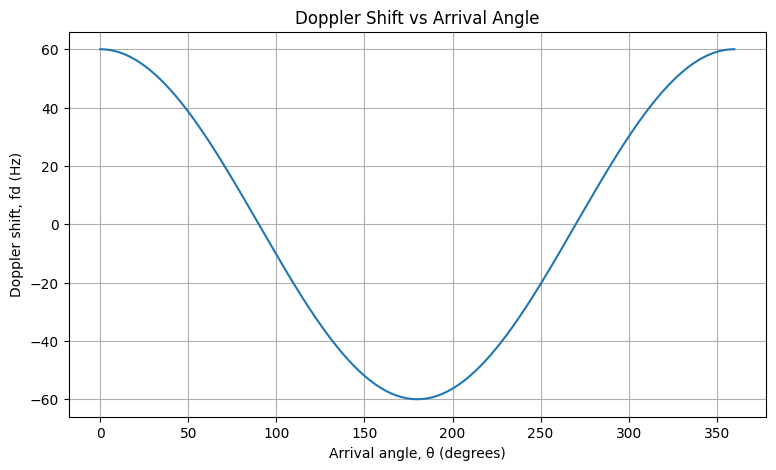

In [2]:
angles_deg = np.linspace(0, 360, 361)
doppler_hz = max_doppler_hz * np.cos(np.deg2rad(angles_deg))

plt.figure(figsize=(9, 5))
plt.plot(angles_deg, doppler_hz)
plt.xlabel("Arrival angle, θ (degrees)")
plt.ylabel("Doppler shift, fd (Hz)")
plt.title("Doppler Shift vs Arrival Angle")
plt.grid(True)
plt.show()

**Observation:** The shift is maximum positive at $0^\circ$, zero at $90^\circ$ and $270^\circ$, and maximum negative at $180^\circ$. Thus the same mobile speed can produce different Doppler shifts depending on direction.

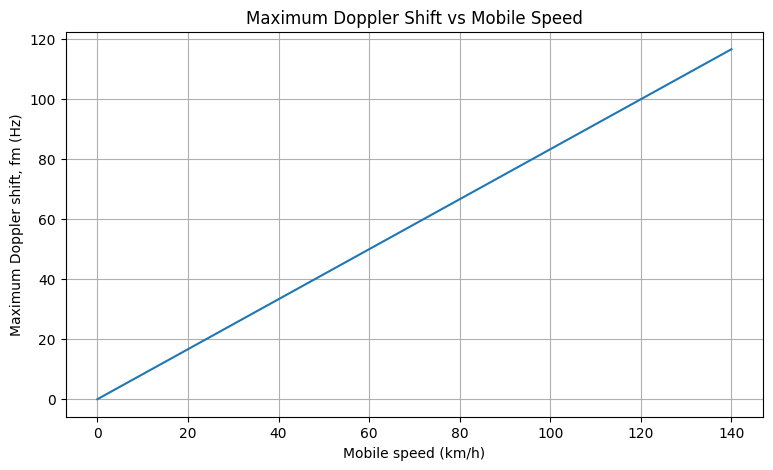

In [3]:
speeds_kmh = np.linspace(0, 140, 141)
speeds_ms = speeds_kmh / 3.6
max_doppler_vs_speed = speeds_ms * carrier_frequency_hz / c

plt.figure(figsize=(9, 5))
plt.plot(speeds_kmh, max_doppler_vs_speed)
plt.xlabel("Mobile speed (km/h)")
plt.ylabel("Maximum Doppler shift, fm (Hz)")
plt.title("Maximum Doppler Shift vs Mobile Speed")
plt.grid(True)
plt.show()

**Observation:** For a fixed carrier frequency, maximum Doppler shift increases linearly with mobile speed.

In [4]:
measured_max_doppler_hz = 100.0
estimated_speed_ms = measured_max_doppler_hz * c / carrier_frequency_hz
estimated_speed_kmh = estimated_speed_ms * 3.6

print(f"For a measured maximum Doppler of {measured_max_doppler_hz:.1f} Hz:")
print(f"Estimated speed = {estimated_speed_ms:.2f} m/s")
print(f"Estimated speed = {estimated_speed_kmh:.2f} km/h")

For a measured maximum Doppler of 100.0 Hz:
Estimated speed = 33.33 m/s
Estimated speed = 120.00 km/h


## Result and Discussion

The experiment demonstrates that Doppler shift depends on three main quantities: carrier frequency, mobile speed, and direction of motion. A higher carrier frequency or a higher speed produces a larger maximum Doppler shift. The angular plot also shows why a multipath mobile channel may contain several Doppler components at the same time.

## Conclusion

Doppler shift was calculated successfully using the standard mobile-radio relationship. The inverse relationship was also used to estimate maximum mobile velocity from a known Doppler frequency.

## Viva Questions and Short Answers

1. **What causes Doppler shift?**  
   Relative motion between the mobile and the arriving radio wave.

2. **When is Doppler shift maximum?**  
   When the motion is directly toward or directly away from the wave direction.

3. **What is the Doppler shift at $\theta=90^\circ$?**  
   Zero, because $\cos90^\circ=0$.

4. **What happens to Doppler shift if carrier frequency increases?**  
   Its magnitude increases for the same mobile speed.

5. **What is maximum Doppler frequency?**  
   The largest magnitude of Doppler shift possible for the given speed and carrier frequency.

---

<a id="exp02"></a>

# Experiment 02: Calculation of Co-channel Reuse Distance and Reuse Ratio

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 3 (frequency reuse, cluster/reuse geometry) and ICT-4203 Master Study Notes formulas used by the course.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To calculate the cluster size, co-channel reuse distance, and reuse ratio of a cellular system.

## Objectives

- Understand frequency reuse and co-channel cells.
- Generate valid hexagonal cluster sizes from shift parameters $(i,j)$.
- Calculate reuse distance $D$.
- Calculate reuse ratio $q=D/R$.
- Observe the capacity-versus-interference trade-off.

## Theory

**Frequency reuse** allows the same radio channels to be used in different cells that are separated by enough distance to keep co-channel interference within an acceptable level.

For the common hexagonal cellular model, a valid cluster size is

$$
N=i^2+ij+j^2
$$

where $i$ and $j$ are non-negative integers that describe the shift between co-channel cells.

If $R$ is the cell radius and $D$ is the distance between the centers of nearest co-channel cells, then

$$
D=R\sqrt{3N}
$$

The **co-channel reuse ratio** (also called the co-channel interference reduction factor in the course material) is

$$
q=\frac{D}{R}=\sqrt{3N}
$$

A larger $N$ gives a larger reuse distance and generally reduces co-channel interference, but the same spectrum is reused less frequently. A smaller $N$ improves capacity but requires stronger interference control.

## Procedure

1. Select cell radius $R$ and shift parameters $(i,j)$.
2. Calculate cluster size $N=i^2+ij+j^2$.
3. Calculate $q=\sqrt{3N}$.
4. Calculate $D=Rq$.
5. Repeat for several valid cluster sizes and compare the results graphically.

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Configurable parameters
R_km = 1.0
i = 2
j = 1

N = i**2 + i*j + j**2
q = np.sqrt(3 * N)
D_km = R_km * q

print(f"Shift parameters (i, j) = ({i}, {j})")
print(f"Cluster size N          = {N}")
print(f"Cell radius R           = {R_km:.2f} km")
print(f"Reuse ratio q           = {q:.4f}")
print(f"Reuse distance D        = {D_km:.4f} km")

Shift parameters (i, j) = (2, 1)
Cluster size N          = 7
Cell radius R           = 1.00 km
Reuse ratio q           = 4.5826
Reuse distance D        = 4.5826 km


### Numerical Example

For $i=2$, $j=1$:

$$
N=2^2+(2)(1)+1^2=7
$$

Therefore,

$$
q=\sqrt{3(7)}=\sqrt{21}\approx4.583
$$

If $R=1$ km,

$$
D=1\times4.583\approx4.583\text{ km}
$$

### Visualization of the Cellular Frequency Reuse Pattern

In a regular hexagonal cellular geometry, the distance between the centers of any two adjacent cells sharing a common face is $\sqrt{3}R$, where $R$ is the cell radius. The cellular grid can be represented using two basis displacement vectors separated by an angle of $60^\circ$:

$$
\mathbf{u}_1 = (\sqrt{3}R,\, 0), \qquad \mathbf{u}_2 = \left(\frac{\sqrt{3}}{2}R,\, \frac{3}{2}R\right)
$$

To locate the nearest co-channel cells (cells reusing the identical set of frequency channels) for a cluster size $N$, the standard cellular engineering shift rule is:

1. Move $i$ cells along any chain of hexagons (along $\mathbf{u}_1$).
2. Turn $60^\circ$ counter-clockwise and move $j$ cells (along $\mathbf{u}_2$).

The resulting center-to-center displacement vector between the two co-channel cells is:

$$
\mathbf{D} = i\mathbf{u}_1 + j\mathbf{u}_2
$$

Evaluating the magnitude squared of this displacement via vector addition in the $60^\circ$ coordinate system yields:

$$
D^2 = \|\mathbf{D}\|^2 = (i\sqrt{3}R)^2 + (j\sqrt{3}R)^2 + 2(i\sqrt{3}R)(j\sqrt{3}R)\cos(60^\circ) = 3R^2(i^2 + j^2 + ij) = 3N R^2
$$

Thus, the theoretical co-channel reuse distance is:

$$
D = R\sqrt{3N}
$$

and the co-channel reuse ratio (interference reduction factor) is:

$$
q = \frac{D}{R} = \sqrt{3N}
$$

For $i = 2$, $j = 1$, and $R = 1.0\text{ km}$:

$$
N = 2^2 + (2)(1) + 1^2 = 7, \qquad q = \sqrt{21} \approx 4.5826, \qquad D = 1.0 \times \sqrt{21} \approx 4.5826\text{ km}
$$

In a cluster of size $N = 7$, the available radio spectrum is divided into seven disjoint frequency groups, denoted $F_1, F_2, \dots, F_7$. Below, we visualize this frequency-reuse pattern on a hexagonal grid, highlighting the reference cell $(0, 0)$ and its nearest co-channel neighbor $(2, 1)$, both allocated frequency group $F_1$.

Cluster size N                  = 7
Cell radius R                   = 1.00 km
Reuse ratio q                   = 4.5826
Co-channel reuse distance D     = 4.5826 km
Distance between cell centers   = 4.5826 km
Numerical verification (dist==D): True


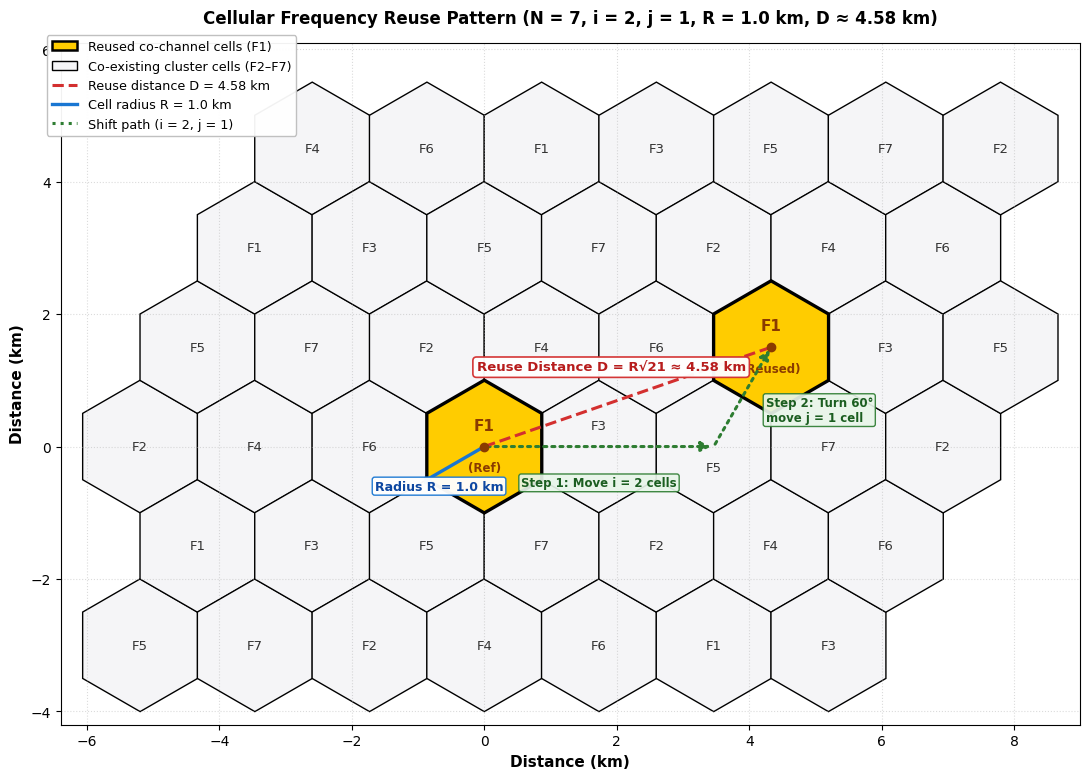

In [6]:
from matplotlib.patches import Polygon, Patch
from matplotlib.lines import Line2D

# Configurable parameters for frequency reuse visualization
R_reuse_km = 1.0
R_draw_km = R_reuse_km * 1.002  # drawing overlap to eliminate raster hairlines
i_shift = 2
j_shift = 1

N_reuse = i_shift**2 + i_shift * j_shift + j_shift**2
q_reuse = np.sqrt(3 * N_reuse)
D_reuse_km = R_reuse_km * q_reuse

# Pointy-top hexagon vertex angles (points at top and bottom: 30°, 90°, 150°, 210°, 270°, 330°)
angles = np.array([30, 90, 150, 210, 270, 330]) * np.pi / 180.0

def get_hexagon_vertices(center, radius):
    """Return 6x2 array of vertices for a pointy-top hexagon centered at center."""
    x = center[0] + radius * np.cos(angles)
    y = center[1] + radius * np.sin(angles)
    return np.column_stack([x, y])

# Basis vectors for pointy-top hexagon centers (adjacent center distance = sqrt(3)*R)
d_step = np.sqrt(3) * R_reuse_km
u1 = np.array([d_step, 0.0])
u2 = np.array([d_step * 0.5, d_step * np.sqrt(3) / 2.0])

# Coordinates of reference cell (0, 0) and nearest co-channel cell (i, j)
ref_idx = (0, 0)
target_idx = (i_shift, j_shift)
c_ref = ref_idx[0] * u1 + ref_idx[1] * u2
c_target = target_idx[0] * u1 + target_idx[1] * u2

# Numerically calculate Euclidean distance between the two cell centers
center_distance_km = np.linalg.norm(c_target - c_ref)
distance_verified = np.isclose(center_distance_km, D_reuse_km)

# Print values before displaying the figure
print(f"Cluster size N                  = {N_reuse}")
print(f"Cell radius R                   = {R_reuse_km:.2f} km")
print(f"Reuse ratio q                   = {q_reuse:.4f}")
print(f"Co-channel reuse distance D     = {D_reuse_km:.4f} km")
print(f"Distance between cell centers   = {center_distance_km:.4f} km")
print(f"Numerical verification (dist==D): {distance_verified}")

# Construct hexagonal grid cells with frequency group assignment F1..F7
cells_to_draw = []
for u in range(-3, 5):
    for v in range(-2, 4):
        pos = u * u1 + v * u2
        if -5.5 <= pos[0] <= 8.5 and -4.0 <= pos[1] <= 5.0:
            freq = ((2 * u + 3 * v) % 7) + 1
            cells_to_draw.append((u, v, pos, freq))

fig, ax = plt.subplots(figsize=(11, 8.5))

# Draw each cell using Polygon with manually computed vertices
for u, v, pos, freq in cells_to_draw:
    is_ref = (u == ref_idx[0] and v == ref_idx[1])
    is_target = (u == target_idx[0] and v == target_idx[1])
    is_highlighted = is_ref or is_target

    verts = get_hexagon_vertices(pos, R_draw_km)
    facecolor = '#FFCC00' if is_highlighted else '#F5F5F7'
    edgecolor = 'black'
    linewidth = 2.4 if is_highlighted else 1.0

    poly = Polygon(
        verts, closed=True,
        facecolor=facecolor, edgecolor=edgecolor, linewidth=linewidth,
        zorder=2 if is_highlighted else 1
    )
    ax.add_patch(poly)

    # Label cells
    if is_ref:
        ax.text(pos[0], pos[1] + 0.32, "F1", ha='center', va='center',
                fontsize=11, fontweight='bold', color='#8A3B00', zorder=4)
        ax.text(pos[0], pos[1] - 0.32, "(Ref)", ha='center', va='center',
                fontsize=8.5, fontweight='bold', color='#8A3B00', zorder=4)
    elif is_target:
        ax.text(pos[0], pos[1] + 0.32, "F1", ha='center', va='center',
                fontsize=11, fontweight='bold', color='#8A3B00', zorder=4)
        ax.text(pos[0], pos[1] - 0.32, "(Reused)", ha='center', va='center',
                fontsize=8.5, fontweight='bold', color='#8A3B00', zorder=4)
    elif (u, v) == (1, 0):
        ax.text(pos[0], pos[1] + 0.32, f"F{freq}", ha='center', va='center',
                fontsize=9.5, color='#333333', zorder=3)
    elif (u, v) == (2, 0):
        ax.text(pos[0], pos[1] - 0.32, f"F{freq}", ha='center', va='center',
                fontsize=9.5, color='#333333', zorder=3)
    else:
        ax.text(pos[0], pos[1], f"F{freq}", ha='center', va='center',
                fontsize=9.5, color='#333333', zorder=3)

# Highlight cell centers
ax.plot(c_ref[0], c_ref[1], 'o', color='#8A3B00', markersize=6, zorder=6)
ax.plot(c_target[0], c_target[1], 'o', color='#8A3B00', markersize=6, zorder=6)

# 1. Co-channel reuse distance D line
ax.plot([c_ref[0], c_target[0]], [c_ref[1], c_target[1]],
        color='#D32F2F', linestyle='--', linewidth=2.2, zorder=5)

mid_D = (c_ref + c_target) / 2.0
ax.text(
    mid_D[0] - 0.25, mid_D[1] + 0.35,
    f"Reuse Distance D = R√21 ≈ {D_reuse_km:.2f} km",
    fontsize=9.5, fontweight='bold', color='#B71C1C',
    ha='center', va='bottom',
    bbox=dict(boxstyle='round,pad=0.28', facecolor='#FFFFFF', edgecolor='#D32F2F', linewidth=1.2, alpha=0.96),
    zorder=7
)

# 2. Cell radius R line in reference cell (center to bottom-left vertex)
v_bl = c_ref + np.array([-np.sqrt(3) / 2.0 * R_reuse_km, -0.5 * R_reuse_km])
ax.plot([c_ref[0], v_bl[0]], [c_ref[1], v_bl[1]],
        color='#1976D2', linestyle='-', linewidth=2.4, zorder=5)
ax.plot(v_bl[0], v_bl[1], 's', color='#1976D2', markersize=4, zorder=6)
mid_R = (c_ref + v_bl) / 2.0
ax.text(
    mid_R[0] - 0.25, mid_R[1] - 0.25,
    f"Radius R = {R_reuse_km:.1f} km",
    fontsize=9, fontweight='bold', color='#0D47A1',
    ha='center', va='top',
    bbox=dict(boxstyle='round,pad=0.2', facecolor='#FFFFFF', edgecolor='#1976D2', linewidth=1.0, alpha=0.96),
    zorder=7
)

# 3. Shift trajectory (i = 2, j = 1)
step_i_end = c_ref + i_shift * u1
ax.annotate("", xy=step_i_end, xytext=c_ref,
            arrowprops=dict(arrowstyle="-|>", color='#2E7D32', linestyle=':', lw=2.2, mutation_scale=14),
            zorder=4)
ax.annotate("", xy=c_target, xytext=step_i_end,
            arrowprops=dict(arrowstyle="-|>", color='#2E7D32', linestyle=':', lw=2.2, mutation_scale=14),
            zorder=4)

ax.text(step_i_end[0] / 2.0, step_i_end[1] - 0.45, f"Step 1: Move i = {i_shift} cells",
        ha='center', va='top', fontsize=8.5, color='#1B5E20', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#E8F5E9', edgecolor='#2E7D32', alpha=0.92),
        zorder=6)

mid_j = (step_i_end + c_target) / 2.0
ax.text(mid_j[0] + 0.35, mid_j[1] - 0.2, f"Step 2: Turn 60°\nmove j = {j_shift} cell",
        ha='left', va='center', fontsize=8.5, color='#1B5E20', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#E8F5E9', edgecolor='#2E7D32', alpha=0.92),
        zorder=6)

# Labels, title, grid, equal aspect ratio
ax.set_xlabel("Distance (km)", fontsize=11, fontweight='semibold')
ax.set_ylabel("Distance (km)", fontsize=11, fontweight='semibold')
ax.set_title(
    f"Cellular Frequency Reuse Pattern (N = {N_reuse}, i = {i_shift}, j = {j_shift}, R = {R_reuse_km:.1f} km, D ≈ {D_reuse_km:.2f} km)",
    fontsize=12, fontweight='bold', pad=14
)
ax.set_aspect('equal')
ax.grid(True, linestyle=':', alpha=0.45)

# Clear legend
legend_elements = [
    Patch(facecolor='#FFCC00', edgecolor='black', linewidth=1.8, label='Reused co-channel cells (F1)'),
    Patch(facecolor='#F5F5F7', edgecolor='black', linewidth=1.0, label='Co-existing cluster cells (F2–F7)'),
    Line2D([0], [0], color='#D32F2F', linestyle='--', linewidth=2.2, label=f'Reuse distance D = {D_reuse_km:.2f} km'),
    Line2D([0], [0], color='#1976D2', linestyle='-', linewidth=2.4, label=f'Cell radius R = {R_reuse_km:.1f} km'),
    Line2D([0], [0], color='#2E7D32', linestyle=':', linewidth=2.2, label=f'Shift path (i = {i_shift}, j = {j_shift})'),
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(-0.02, 1.02),
          framealpha=0.95, edgecolor='#BDBDBD', fontsize=9.2)

all_x = [p[0] for _, _, p, _ in cells_to_draw]
all_y = [p[1] for _, _, p, _ in cells_to_draw]
ax.set_xlim(min(all_x) - 1.2, max(all_x) + 1.2)
ax.set_ylim(min(all_y) - 1.2, max(all_y) + 1.6)

plt.tight_layout()
plt.show()

**Observation:** The spatial layout illustrates the fundamental cellular engineering trade-off between network capacity and co-channel interference:

1. **Interference reduction with larger cluster size:** By separating co-channel $F_1$ cells by a distance $D = R\sqrt{3N} \approx 4.58\text{ km}$ (a reuse ratio $q = \sqrt{21} \approx 4.583$), propagation attenuation keeps co-channel interference ($CCI$) sufficiently low, achieving an acceptable signal-to-interference ratio ($S/I$). Increasing $N$ places co-channel base stations farther apart, lowering co-channel interference and improving link quality.
2. **Capacity cost of large clusters:** However, because the total frequency spectrum must be partitioned among $N$ distinct cell groups, each individual cell receives only $1/N$ of the available channels. A larger cluster size therefore reduces the traffic channel capacity per cell.
3. **Capacity benefit of smaller clusters:** Conversely, a smaller cluster size (such as $N = 4$ or $N = 3$) allocates more channels to each cell, increasing overall spectral efficiency and subscriber capacity per square kilometer. The trade-off is a reduced co-channel reuse distance $D$, which increases interference and requires tighter interference management (e.g., cell sectoring or power control).

In [7]:
# Generate valid cluster sizes for small i and j
valid = set()
for ii in range(0, 5):
    for jj in range(0, 5):
        if ii == 0 and jj == 0:
            continue
        valid.add(ii**2 + ii*jj + jj**2)

valid_cluster_sizes = np.array(sorted(valid))
reuse_ratios = np.sqrt(3 * valid_cluster_sizes)
reuse_distances = R_km * reuse_ratios

print("Some valid cluster sizes:", valid_cluster_sizes.tolist())

Some valid cluster sizes: [1, 3, 4, 7, 9, 12, 13, 16, 19, 21, 27, 28, 37, 48]


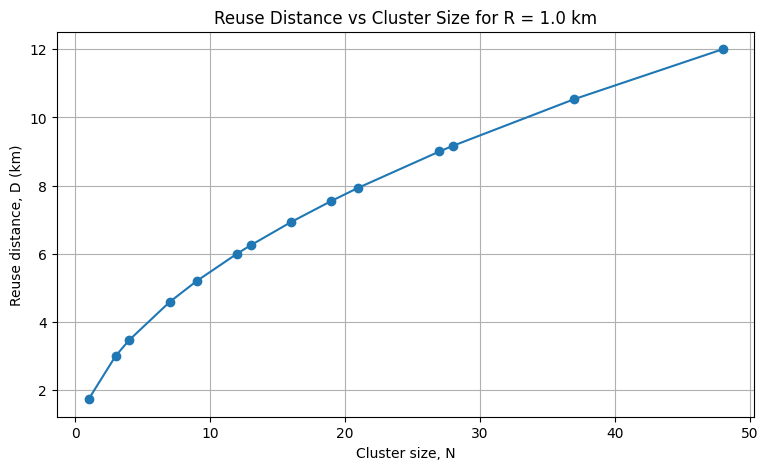

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(valid_cluster_sizes, reuse_distances, marker="o")
plt.xlabel("Cluster size, N")
plt.ylabel("Reuse distance, D (km)")
plt.title(f"Reuse Distance vs Cluster Size for R = {R_km:.1f} km")
plt.grid(True)
plt.show()

**Observation:** Reuse distance increases with cluster size. Thus co-channel cells are placed farther apart when a larger cluster is used.

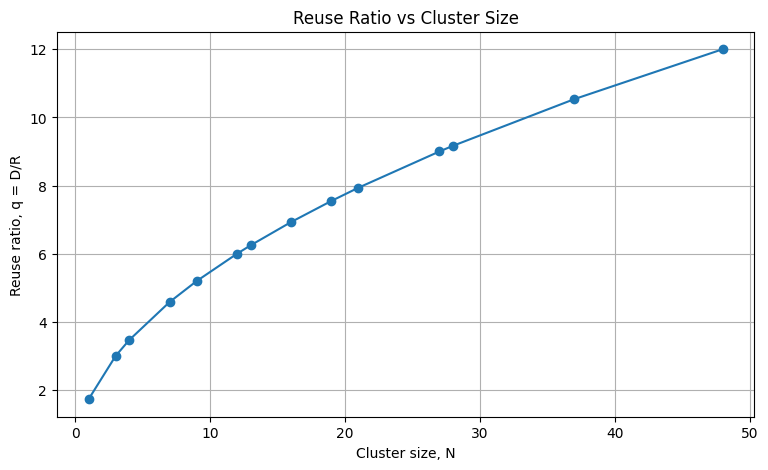

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(valid_cluster_sizes, reuse_ratios, marker="o")
plt.xlabel("Cluster size, N")
plt.ylabel("Reuse ratio, q = D/R")
plt.title("Reuse Ratio vs Cluster Size")
plt.grid(True)
plt.show()

## Result and Discussion

For the example $N=7$ and $R=1$ km, the reuse ratio is approximately **4.583** and the nearest co-channel reuse distance is approximately **4.583 km**. Increasing $N$ increases both $q$ and $D$, which improves co-channel separation but reduces how frequently a channel set can be reused.

## Conclusion

The standard hexagonal frequency-reuse equations were implemented successfully and the relation between cluster size, reuse ratio, and co-channel distance was verified.

## Viva Questions and Short Answers

1. **What is frequency reuse?**  
   Reusing the same channel set in geographically separated cells.

2. **What are co-channel cells?**  
   Cells that use the same radio frequencies.

3. **What is the reuse ratio?**  
   $q=D/R$.

4. **Why does a larger cluster reduce interference?**  
   It increases the separation between co-channel cells.

5. **What is the trade-off of increasing $N$?**  
   Lower co-channel interference but less frequent spectrum reuse and lower capacity.

---

<a id="exp03"></a>

# Experiment 03: Study of Frequency Allocation and Channel Assignment in Cellular Networks

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 5 (Frequency Management and Channel Assignment) and the course Master Study Notes.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To study cellular frequency allocation and implement a simple fixed channel assignment model in Python.

## Objectives

- Understand frequency management and channel assignment.
- Distinguish fixed and dynamic/non-fixed channel assignment.
- Allocate channels among cells using a simple reuse-friendly pattern.
- Simulate call demand, served calls, and blocked calls.
- Explain why fixed allocation can leave channels idle in one cell while another cell is congested.

## Theory

In the course material, **frequency management** includes designation of set-up and voice channels, numbering channels, and grouping voice channels into subsets.

**Channel assignment** means allocating particular radio channels to cell sites and mobile units. A cell may receive a channel set on a long-term basis, while a mobile receives one channel from that set only for the duration of a call.

### Fixed Channel Assignment (FCA)

In FCA, each cell has a predetermined channel set:

$$
\mathcal{C}_k=\{\text{channels permanently assigned to cell }k\}
$$

If every channel in $\mathcal{C}_k$ is busy, a new call in that cell is blocked even if another cell has idle channels.

### Dynamic / Non-Fixed Channel Assignment

In dynamic or non-fixed assignment, channels are drawn from a common or adaptable pool according to current demand and interference conditions. This improves flexibility but requires more real-time control.

### Simplified allocation used in this notebook

To avoid assigning many adjacent channel numbers to the same cell, channels are distributed cyclically:

$$
\text{Cell index} = ((\text{channel}-1)\bmod N_c)+1
$$

where $N_c$ is the number of cells in the reuse cluster.

This is an educational allocation rule—not a complete commercial frequency-planning algorithm.

## Procedure

1. Select the number of cells and total available traffic channels.
2. Distribute channels cyclically among cells.
3. Specify busy-hour call demand for each cell.
4. Compare demand with the number of channels assigned to each cell.
5. Count served calls and blocked calls.
6. Plot cell demand versus fixed channel capacity.

In [10]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configurable parameters
number_of_cells = 7
total_channels = 70

def fixed_channel_assignment(total_channels, number_of_cells):
    assignment = {f"Cell {i+1}": [] for i in range(number_of_cells)}
    for channel in range(1, total_channels + 1):
        cell_index = (channel - 1) % number_of_cells
        assignment[f"Cell {cell_index + 1}"].append(channel)
    return assignment

assignment = fixed_channel_assignment(total_channels, number_of_cells)

for cell, channels in assignment.items():
    print(f"{cell}: {channels}")

Cell 1: [1, 8, 15, 22, 29, 36, 43, 50, 57, 64]
Cell 2: [2, 9, 16, 23, 30, 37, 44, 51, 58, 65]
Cell 3: [3, 10, 17, 24, 31, 38, 45, 52, 59, 66]
Cell 4: [4, 11, 18, 25, 32, 39, 46, 53, 60, 67]
Cell 5: [5, 12, 19, 26, 33, 40, 47, 54, 61, 68]
Cell 6: [6, 13, 20, 27, 34, 41, 48, 55, 62, 69]
Cell 7: [7, 14, 21, 28, 35, 42, 49, 56, 63, 70]


**Interpretation:** With 70 channels and 7 cells, each cell receives 10 fixed channels. The channel numbers in one cell are separated by seven channel positions in this simplified pattern.

In [11]:
# Example busy-hour demand: number of simultaneous call requests
call_requests = {
    "Cell 1": 8,
    "Cell 2": 13,
    "Cell 3": 6,
    "Cell 4": 10,
    "Cell 5": 15,
    "Cell 6": 7,
    "Cell 7": 11,
}

rows = []
for cell, channels in assignment.items():
    capacity = len(channels)
    demand = call_requests[cell]
    served = min(capacity, demand)
    blocked = max(0, demand - capacity)
    idle = max(0, capacity - demand)

    rows.append({
        "Cell": cell,
        "Assigned Channels": capacity,
        "Call Requests": demand,
        "Served Calls": served,
        "Blocked Calls": blocked,
        "Idle Channels": idle
    })

df = pd.DataFrame(rows)
df

,Cell,Assigned Channels,Call Requests,Served Calls,Blocked Calls,Idle Channels
0,Cell 1,10,8,8,0,2
1,Cell 2,10,13,10,3,0
2,Cell 3,10,6,6,0,4
3,Cell 4,10,10,10,0,0
4,Cell 5,10,15,10,5,0
5,Cell 6,10,7,7,0,3
6,Cell 7,10,11,10,1,0


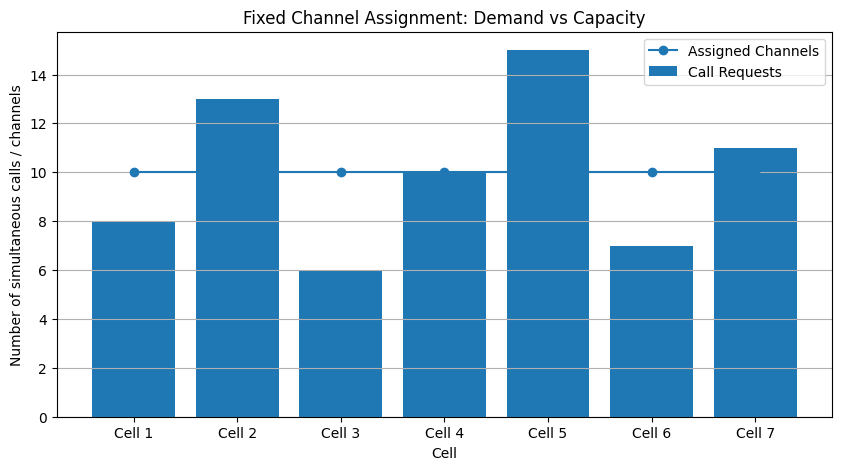

In [12]:
x = np.arange(len(df))

plt.figure(figsize=(10, 5))
plt.bar(x, df["Call Requests"], label="Call Requests")
plt.plot(x, df["Assigned Channels"], marker="o", label="Assigned Channels")
plt.xticks(x, df["Cell"])
plt.xlabel("Cell")
plt.ylabel("Number of simultaneous calls / channels")
plt.title("Fixed Channel Assignment: Demand vs Capacity")
plt.legend()
plt.grid(axis="y")
plt.show()

**Observation:** Cells with demand greater than their fixed capacity block calls. At the same time, some other cells can still have idle channels. This illustrates the resource inflexibility emphasized in the course discussion of FCA.

In [13]:
total_requested = df["Call Requests"].sum()
total_served = df["Served Calls"].sum()
total_blocked = df["Blocked Calls"].sum()
total_idle = df["Idle Channels"].sum()

print(f"Total requested calls : {total_requested}")
print(f"Total served calls    : {total_served}")
print(f"Total blocked calls   : {total_blocked}")
print(f"Total idle channels   : {total_idle}")

Total requested calls : 70
Total served calls    : 61
Total blocked calls   : 9
Total idle channels   : 9


## Fixed vs Dynamic Assignment — Practical Comparison

| Feature | Fixed Channel Assignment | Dynamic / Non-Fixed Assignment |
|---|---|---|
| Channel ownership | Predetermined per cell | Selected according to current need |
| Complexity | Low | Higher |
| Signalling/control | Lower | Higher |
| Response to uneven traffic | Weak | Better |
| Call blocking under local congestion | Can be high | Can be reduced if reusable channels are available |
| Interference control | Planned in advance | Must be checked during assignment |

## Result and Discussion

The notebook allocates a fixed channel set to each cell and demonstrates local blocking under uneven traffic. This is the main weakness of FCA: resources cannot automatically move to a congested cell.

## Conclusion

Frequency allocation and fixed channel assignment were implemented successfully. The simulation clearly shows the difference between **system-wide unused capacity** and **local channel availability**.

## Viva Questions and Short Answers

1. **What is frequency management?**  
   Planning set-up/voice channels, channel numbering, and grouping according to the system plan.

2. **What is channel assignment?**  
   Allocation of radio channels to cells and mobile users.

3. **What is the main idea of FCA?**  
   Each cell receives a predetermined channel set.

4. **Why can FCA block a call even when the network has idle channels?**  
   Because idle channels in another cell are not automatically available to the congested cell.

5. **What is the main advantage of dynamic assignment?**  
   It adapts channel use to current traffic and can improve spectrum utilization.

---

<a id="exp04"></a>

# Experiment 04: Study and Simulation of GSM Network Architecture

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 2 digital cellular/GSM entities; William C. Y. Lee GSM architecture sections; course Master Study Notes.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To study the major GSM network entities and create a simple logical simulation of GSM architecture and call setup.

## Objectives

- Identify MS, BTS, BSC, MSC, HLR, VLR, AUC, EIR, and PSTN.
- Understand the relationship between the mobile station, base-station subsystem, and switching subsystem.
- Visualize a simplified GSM architecture.
- Demonstrate a basic mobile-originated call setup sequence.

## Theory

The course describes a digital cellular system using four main elements: **Mobile Station (MS), Base Transceiver Station (BTS), Base Station Controller (BSC), and switching subsystems**.

### Main GSM Entities

- **MS (Mobile Station):** User equipment; in GSM it includes mobile equipment and subscriber identity information stored in the SIM.
- **BTS (Base Transceiver Station):** Provides the radio transmission/reception link to the mobile.
- **BSC (Base Station Controller):** Controls multiple BTSs and performs radio-resource management, handover control, power management, synchronization, and frequency reallocation.
- **MSC (Mobile Switching Center):** Coordinates call setup and switching between mobile subscribers and external networks.
- **HLR (Home Location Register):** Central subscriber database.
- **VLR (Visitor Location Register):** Temporary subscriber/location data for mobiles currently served by an MSC area.
- **AUC (Authentication Center):** Works with the HLR to supply authentication and ciphering parameters.
- **EIR (Equipment Identity Register):** Stores mobile-equipment identity information.
- **PSTN:** External public telephone network.

### Important GSM Interfaces

A simplified chain is

$$
\text{MS}\xleftrightarrow{\text{Um}}\text{BTS}
\xleftrightarrow{\text{Abis}}\text{BSC}
\xleftrightarrow{\text{A}}\text{MSC}
$$

The architecture simulation below represents logical connectivity, not a packet-level GSM protocol stack.

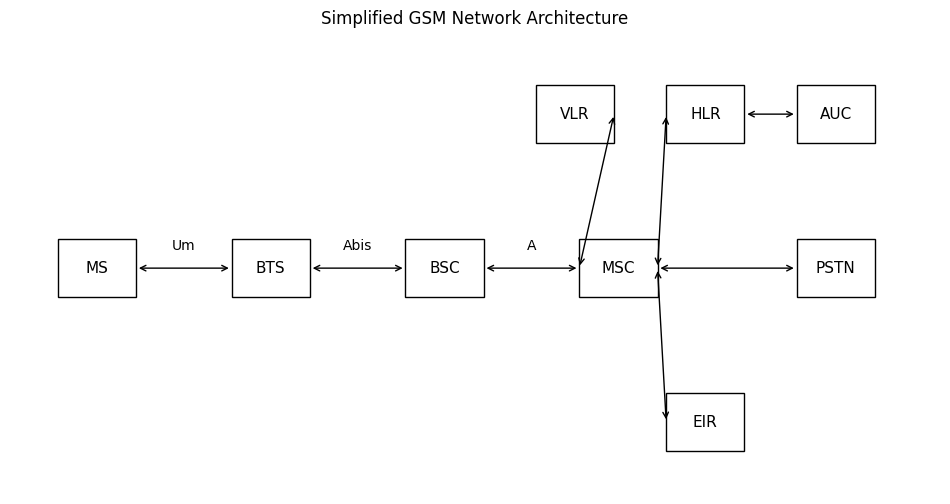

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

nodes = {
    "MS": (0.5, 2.0),
    "BTS": (2.5, 2.0),
    "BSC": (4.5, 2.0),
    "MSC": (6.5, 2.0),
    "PSTN": (9.0, 2.0),
    "HLR": (7.5, 3.5),
    "VLR": (6.0, 3.5),
    "AUC": (9.0, 3.5),
    "EIR": (7.5, 0.5),
}

edges = [
    ("MS", "BTS", "Um"),
    ("BTS", "BSC", "Abis"),
    ("BSC", "MSC", "A"),
    ("MSC", "PSTN", ""),
    ("MSC", "HLR", ""),
    ("MSC", "VLR", ""),
    ("HLR", "AUC", ""),  # the AUC is associated with the HLR
    ("MSC", "EIR", ""),
]

plt.figure(figsize=(12, 6))

for name, (x, y) in nodes.items():
    box = Rectangle((x - 0.45, y - 0.28), 0.9, 0.56, fill=False)
    plt.gca().add_patch(box)
    plt.text(x, y, name, ha="center", va="center", fontsize=11)

for start, end, label in edges:
    x1, y1 = nodes[start]
    x2, y2 = nodes[end]
    plt.annotate(
        "",
        xy=(x2 - 0.45 if x2 > x1 else x2 + 0.45, y2),
        xytext=(x1 + 0.45 if x2 > x1 else x1 - 0.45, y1),
        arrowprops=dict(arrowstyle="<->")  # GSM links are bidirectional
    )
    if label:
        plt.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.18, label, ha="center")

plt.xlim(-0.5, 10.2)
plt.ylim(-0.2, 4.3)
plt.axis("off")
plt.title("Simplified GSM Network Architecture")
plt.show()

**Observation:** The radio path ends at the BTS. The BSC manages radio resources across BTSs, while the MSC connects the radio access side to subscriber databases and external networks.

## Simplified Mobile-Originated Call Setup

A complete GSM call procedure contains many signalling details. For this laboratory, the sequence is deliberately simplified to highlight the roles of the major entities:

1. MS requests access through the BTS.
2. BTS forwards the request toward the BSC.
3. BSC requests call setup from the MSC.
4. MSC checks subscriber/location/security-related information.
5. Radio resources are assigned through BSC/BTS.
6. MSC establishes the connection toward the destination network.

In [15]:
call_setup_steps = [
    ("MS", "BTS", "Random access / service request"),
    ("BTS", "BSC", "Forward access request"),
    ("BSC", "MSC", "Call setup request"),
    ("MSC", "VLR/HLR/AUC", "Subscriber and security checks"),
    ("MSC", "BSC", "Authorize traffic-channel setup"),
    ("BSC", "BTS", "Activate radio traffic channel"),
    ("BTS", "MS", "Assign traffic channel"),
    ("MSC", "PSTN / Destination", "Establish outgoing connection"),
    ("Network", "MS", "Call connected"),
]

for step_number, (source, destination, action) in enumerate(call_setup_steps, start=1):
    print(f"{step_number:02d}. {source:10s} -> {destination:20s}: {action}")

01. MS         -> BTS                 : Random access / service request
02. BTS        -> BSC                 : Forward access request
03. BSC        -> MSC                 : Call setup request
04. MSC        -> VLR/HLR/AUC         : Subscriber and security checks
05. MSC        -> BSC                 : Authorize traffic-channel setup
06. BSC        -> BTS                 : Activate radio traffic channel
07. BTS        -> MS                  : Assign traffic channel
08. MSC        -> PSTN / Destination  : Establish outgoing connection
09. Network    -> MS                  : Call connected


## Result and Discussion

The generated diagram shows the major GSM entities and their logical connections. The call-flow output demonstrates that radio access is handled by the BTS/BSC side while switching and subscriber management are coordinated through the MSC and network databases.

## Conclusion

GSM architecture was studied and represented using a clear Python visualization and a simplified call-setup simulation suitable for an undergraduate laboratory.

## Viva Questions and Short Answers

1. **What is the function of BTS?**  
   It provides the radio transmission and reception link to the mobile station.

2. **What is the main function of BSC?**  
   Radio-resource management for multiple BTSs/cells, including handover and power/frequency management.

3. **What does MSC do?**  
   It coordinates switching and call setup between mobile users and external networks.

4. **What is the difference between HLR and VLR?**  
   HLR is the central subscriber database; VLR stores temporary information for subscribers currently in an MSC area.

5. **What is the role of AUC?**  
   It provides authentication and ciphering parameters for security.

---

<a id="exp05"></a>

# Experiment 05: Simulation of Handover Between Two Cellular Cells

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 3 handoff mechanism; William C. Y. Lee handoff discussion (signal-strength and C/I decision parameters).

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To simulate the handover of a moving mobile from one serving cell to another using received signal strength and a hysteresis margin.

## Objectives

- Understand serving cell, target cell, handover threshold, and hysteresis.
- Model received signal strength from two base stations.
- Simulate a mobile moving from Cell 1 toward Cell 2.
- Detect the handover point.
- Visualize RSS and the serving-cell decision.

## Theory

**Handover (handoff)** is the transfer of an active connection from one cell/base station to another as the mobile moves or radio conditions change.

The course/reference material discusses signal-strength-based handoff as one practical decision method. A simple model is

$$
P_r(d)=P_r(d_0)-10n\log_{10}\left(\frac{d}{d_0}\right)
$$

where $n$ is the path-loss exponent and $d_0$ is the reference distance. This notebook uses $d_0 = 1$ m, so $P_r(d_0)$ is the received level at 1 m.

If the mobile is currently served by BS1, a simple handover rule is

$$
RSS_2 > RSS_1 + H
$$

together with a weak-serving-signal condition

$$
RSS_1 < T_H
$$

where:

- $H$ = hysteresis margin,
- $T_H$ = handover threshold.

**Hysteresis** prevents repeated back-and-forth handovers near the cell boundary (the ping-pong effect).

This notebook uses a deterministic log-distance model so that the handover mechanism is easy to understand and reproduce.

In [16]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Base station positions on a straight road
bs1_position_m = 0.0
bs2_position_m = 1000.0

# Propagation / handover settings
rss_at_1m_dbm = -30.0
path_loss_exponent = 3.0
hysteresis_db = 3.0
handover_threshold_dbm = -105.0

mobile_positions_m = np.linspace(1, 999, 500)

def received_signal_dbm(distance_m, rss_ref_dbm=-30.0, n=3.0):
    distance_m = np.maximum(distance_m, 1.0)
    return rss_ref_dbm - 10 * n * np.log10(distance_m)

rss1 = received_signal_dbm(
    np.abs(mobile_positions_m - bs1_position_m),
    rss_at_1m_dbm,
    path_loss_exponent
)
rss2 = received_signal_dbm(
    np.abs(mobile_positions_m - bs2_position_m),
    rss_at_1m_dbm,
    path_loss_exponent
)

In [17]:
serving_cell = []
current = 1
handover_position_m = None

for x, r1, r2 in zip(mobile_positions_m, rss1, rss2):
    if current == 1:
        if (r2 > r1 + hysteresis_db) and (r1 < handover_threshold_dbm):
            current = 2
            if handover_position_m is None:
                handover_position_m = x
    else:
        if (r1 > r2 + hysteresis_db) and (r2 < handover_threshold_dbm):
            current = 1
    serving_cell.append(current)

serving_cell = np.array(serving_cell)

print(f"Hysteresis margin   : {hysteresis_db:.1f} dB")
print(f"Handover threshold  : {handover_threshold_dbm:.1f} dBm")
print(f"First handover point: {handover_position_m:.1f} m")

Hysteresis margin   : 3.0 dB
Handover threshold  : -105.0 dBm
First handover point: 559.0 m


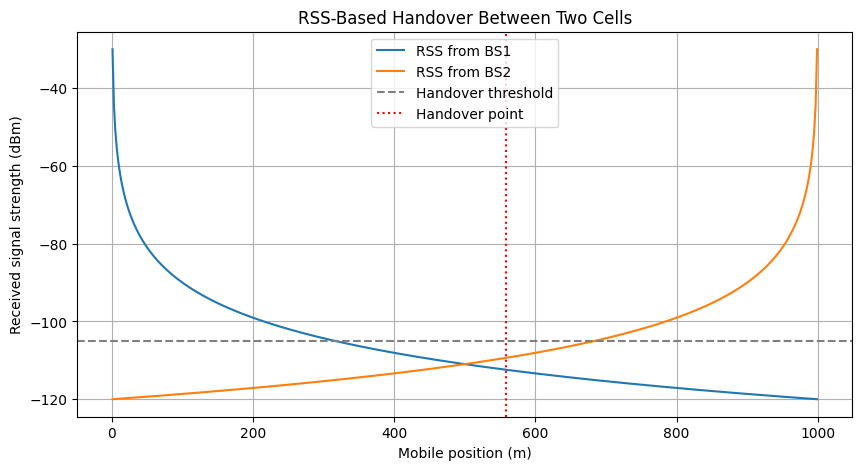

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(mobile_positions_m, rss1, label="RSS from BS1")
plt.plot(mobile_positions_m, rss2, label="RSS from BS2")
plt.axhline(handover_threshold_dbm, color="gray", linestyle="--", label="Handover threshold")
if handover_position_m is not None:
    plt.axvline(handover_position_m, color="red", linestyle=":", label="Handover point")
plt.xlabel("Mobile position (m)")
plt.ylabel("Received signal strength (dBm)")
plt.title("RSS-Based Handover Between Two Cells")
plt.legend()
plt.grid(True)
plt.show()

**Observation:** Near BS1, $RSS_1$ is stronger. As the mobile approaches BS2, $RSS_2$ rises while $RSS_1$ falls. The handover is delayed until the target is sufficiently stronger **and** the serving signal is below the selected threshold.

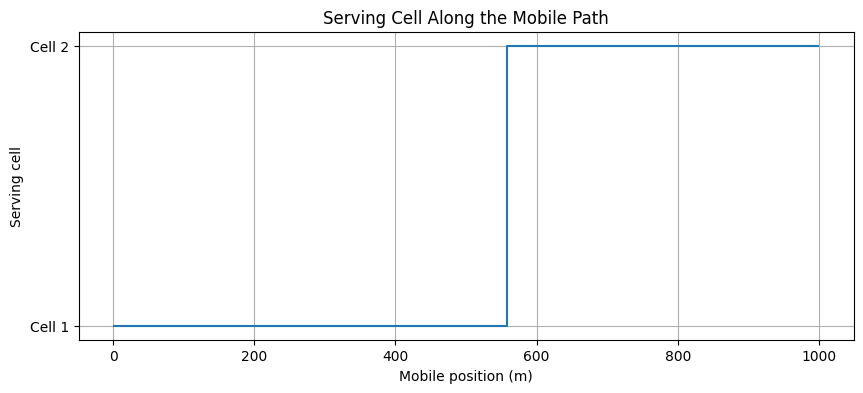

In [19]:
plt.figure(figsize=(10, 4))
plt.step(mobile_positions_m, serving_cell, where="mid")
plt.xlabel("Mobile position (m)")
plt.ylabel("Serving cell")
plt.yticks([1, 2], ["Cell 1", "Cell 2"])
plt.title("Serving Cell Along the Mobile Path")
plt.grid(True)
plt.show()

## Result and Discussion

The simulation produces a single stable handover from Cell 1 to Cell 2. The hysteresis margin prevents a decision based on a very small RSS difference, and the threshold prevents an unnecessarily early handover.

In a real network, decisions can also use interference, quality measurements, load, timing, and technology-specific measurements. This experiment intentionally isolates the basic handover idea.

## Conclusion

Handover between two cells was simulated successfully using RSS, threshold, and hysteresis.

## Viva Questions and Short Answers

1. **Why is handover necessary?**  
   To maintain an active connection as a user moves between coverage areas.

2. **What is hysteresis in handover?**  
   A margin requiring the target signal to be sufficiently stronger before handover.

3. **What is ping-pong handover?**  
   Rapid repeated handovers between neighboring cells.

4. **What is a serving cell?**  
   The cell currently carrying the mobile's connection.

5. **Can handover use parameters other than RSS?**  
   Yes. Signal quality, interference, load, and technology-specific measurements may also be used.

---

<a id="exp06"></a>

# Experiment 06: Received Signal Strength-Based Base Station Selection

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 4 cell-coverage concepts and William C. Y. Lee RSS/handoff discussion; implementation is a simplified RSS-only selection model.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To select the most suitable base station for a moving mobile using received signal strength (RSS).

## Objectives

- Calculate RSS from multiple base stations.
- Compare the received levels at each mobile position.
- Select the base station with the strongest RSS.
- Visualize cell-selection regions along a mobile path.

## Theory

A mobile may receive signals from several nearby base stations. A basic cell-selection rule is to choose the base station with the largest received signal strength:

$$
BS_{\text{selected}}(x)
=
\arg\max_i RSS_i(x)
$$

For this experiment, RSS is modeled with the log-distance relationship

$$
RSS_i(d)=RSS(d_0)-10n\log_{10}\left(\frac{d_i}{d_0}\right)
$$

where:

- $RSS(d_0)$ is the reference received level at distance $d_0$ (here $d_0 = 1$ m),
- $d_i$ is distance to base station $i$,
- $n$ is the path-loss exponent.

The course material emphasizes that cell coverage depends on signal strength and distance, and the reference text discusses RSS as a handoff/selection-related measurement. This notebook turns that idea into a simple base-station-selection experiment.

> Real cellular selection additionally uses technology-specific measurements, minimum quality criteria, priorities, and load/control information. The present model intentionally uses RSS only.

In [20]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Base stations placed along a straight road
bs_positions_m = np.array([0.0, 500.0, 1000.0])
mobile_positions_m = np.linspace(1, 999, 500)

rss_reference_dbm = -30.0
path_loss_exponent = 3.0

def calculate_rss_dbm(mobile_x_m, bs_x_m, rss_ref_dbm, n):
    distance_m = np.abs(mobile_x_m - bs_x_m)
    distance_m = np.maximum(distance_m, 1.0)
    return rss_ref_dbm - 10 * n * np.log10(distance_m)

rss_matrix = np.array([
    calculate_rss_dbm(
        mobile_positions_m,
        bs_x,
        rss_reference_dbm,
        path_loss_exponent
    )
    for bs_x in bs_positions_m
])

selected_bs = np.argmax(rss_matrix, axis=0) + 1

In [21]:
# Show sample decisions
sample_positions = [100, 300, 500, 700, 900]

for position in sample_positions:
    idx = np.argmin(np.abs(mobile_positions_m - position))
    values = rss_matrix[:, idx]
    print(
        f"At x={mobile_positions_m[idx]:.0f} m: "
        f"RSS={np.round(values, 2)} dBm -> select BS{selected_bs[idx]}"
    )

At x=99 m: RSS=[ -89.87 -108.09 -118.64] dBm -> select BS1
At x=299 m: RSS=[-104.27  -99.1  -115.37] dBm -> select BS2
At x=499 m: RSS=[-110.94  -30.   -111.  ] dBm -> select BS2
At x=699 m: RSS=[-115.33  -98.97 -104.36] dBm -> select BS2
At x=899 m: RSS=[-118.61 -108.03  -90.13] dBm -> select BS3


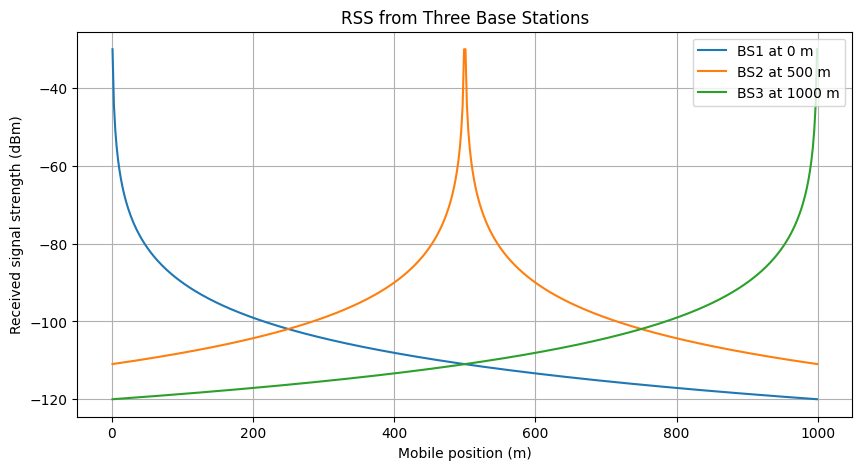

In [22]:
plt.figure(figsize=(10, 5))
for i in range(len(bs_positions_m)):
    plt.plot(
        mobile_positions_m,
        rss_matrix[i],
        label=f"BS{i+1} at {bs_positions_m[i]:.0f} m"
    )

plt.xlabel("Mobile position (m)")
plt.ylabel("Received signal strength (dBm)")
plt.title("RSS from Three Base Stations")
plt.legend()
plt.grid(True)
plt.show()

**Observation:** Each base station dominates the region closest to it. The crossover points occur where two RSS curves become equal. The sharp peak of the BS2 curve appears because the sampled path passes within 1 m of BS2, where the modeled RSS equals the reference level of $-30$ dBm.

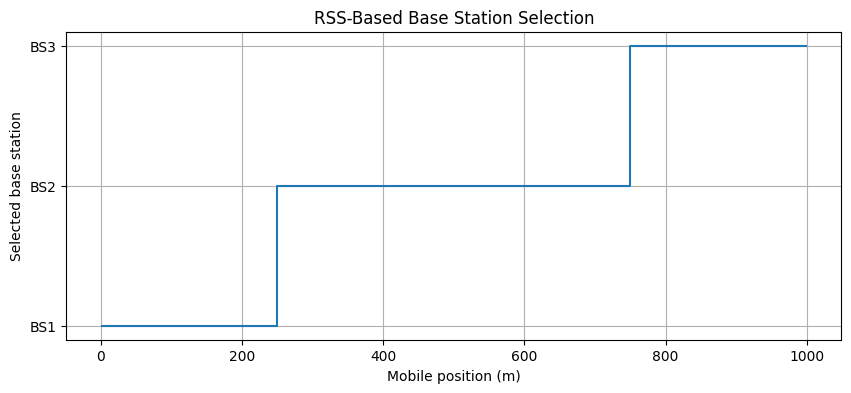

In [23]:
plt.figure(figsize=(10, 4))
plt.step(mobile_positions_m, selected_bs, where="mid")
plt.xlabel("Mobile position (m)")
plt.ylabel("Selected base station")
plt.yticks([1, 2, 3], ["BS1", "BS2", "BS3"])
plt.title("RSS-Based Base Station Selection")
plt.grid(True)
plt.show()

## Result and Discussion

The mobile automatically selects the base station with the strongest modeled RSS. With equally powered and equally spaced base stations in a symmetric environment, the selection boundaries occur close to the midpoints between neighboring sites.

## Conclusion

RSS-based base-station selection was implemented successfully using a simple log-distance propagation model.

## Viva Questions and Short Answers

1. **What is RSS?**  
   Received Signal Strength, usually expressed in dBm.

2. **What selection rule is used here?**  
   Choose the base station with the maximum RSS.

3. **Why does RSS decrease with distance?**  
   Propagation loss increases as the transmitter-receiver separation increases.

4. **What does the path-loss exponent represent?**  
   How rapidly average received power decreases with distance in the environment.

5. **Why is RSS-only selection simplified?**  
   Real networks also consider quality, interference, priorities, load, and protocol rules.

---

<a id="exp07"></a>

# Experiment 07: Free-Space Path Loss and Received Power Analysis Using MATLAB

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 4 propagation models / Master Study Notes (FSPL as ideal LOS); standard Friis/FSPL equations used for the Python implementation.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Implementation Note

The official practical sheet names this experiment **“Free-Space Path Loss and Received Power Analysis Using MATLAB.”**  
This repository implements the same experiment in **Python/Jupyter Notebook**, as requested for the laboratory repository.

## Aim

To calculate free-space path loss and received power as functions of distance and frequency.

## Objectives

- Understand the ideal free-space propagation model.
- Calculate FSPL in decibels.
- Apply a simple link-budget equation.
- Observe how path loss and received power vary with distance.

## Theory

The course material lists **Free-Space Path Loss (FSPL)** as an ideal line-of-sight propagation model with no obstruction.

From the Friis free-space relation,

$$
P_r=P_tG_tG_r\left(\frac{\lambda}{4\pi d}\right)^2
$$

where $P_t$ and $P_r$ are transmitted and received power, $G_t$ and $G_r$ are antenna gains, $\lambda$ is wavelength, and $d$ is separation distance.

The free-space path loss is

$$
FSPL=\left(\frac{4\pi d}{\lambda}\right)^2
$$

In decibels, when $d$ is in **km** and $f$ is in **MHz**,

$$
FSPL_{\text{dB}}
=
32.44
+20\log_{10}(d_{\text{km}})
+20\log_{10}(f_{\text{MHz}})
$$

A simple received-power link budget is

$$
P_r(\text{dBm})
=
P_t(\text{dBm})
+G_t(\text{dBi})
+G_r(\text{dBi})
-FSPL(\text{dB})
-L(\text{dB})
$$

where $L$ represents additional system losses.

In [24]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configurable parameters
frequency_mhz = 900.0
transmit_power_dbm = 43.0
tx_gain_dbi = 15.0
rx_gain_dbi = 0.0
additional_losses_db = 2.0

distance_km = np.linspace(0.1, 20.0, 400)

def fspl_db(distance_km, frequency_mhz):
    distance_km = np.maximum(distance_km, 1e-9)
    return (
        32.44
        + 20 * np.log10(distance_km)
        + 20 * np.log10(frequency_mhz)
    )

path_loss_db = fspl_db(distance_km, frequency_mhz)

received_power_dbm = (
    transmit_power_dbm
    + tx_gain_dbi
    + rx_gain_dbi
    - path_loss_db
    - additional_losses_db
)

In [25]:
check_distances_km = np.array([0.1, 1, 5, 10, 20], dtype=float)
check_fspl = fspl_db(check_distances_km, frequency_mhz)
check_pr = (
    transmit_power_dbm
    + tx_gain_dbi
    + rx_gain_dbi
    - check_fspl
    - additional_losses_db
)

table = pd.DataFrame({
    "Distance (km)": check_distances_km,
    "FSPL (dB)": np.round(check_fspl, 2),
    "Received Power (dBm)": np.round(check_pr, 2)
})

table

,Distance (km),FSPL (dB),Received Power (dBm)
0,0.1,71.52,-15.52
1,1.0,91.52,-35.52
2,5.0,105.50,-49.50
3,10.0,111.52,-55.52
4,20.0,117.55,-61.55


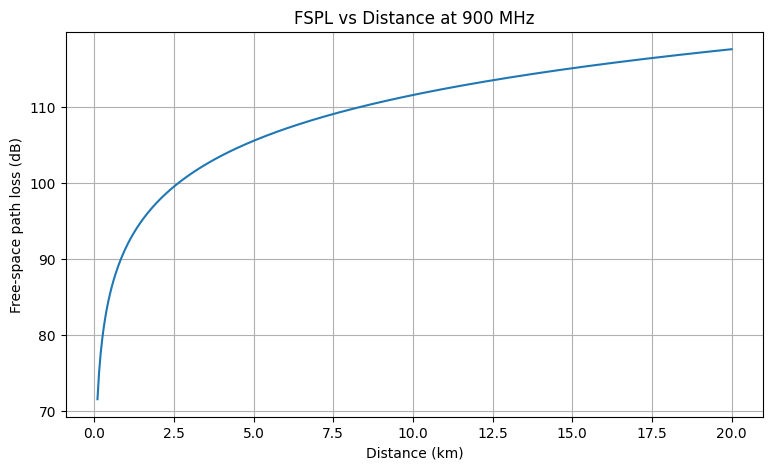

In [26]:
plt.figure(figsize=(9, 5))
plt.plot(distance_km, path_loss_db)
plt.xlabel("Distance (km)")
plt.ylabel("Free-space path loss (dB)")
plt.title(f"FSPL vs Distance at {frequency_mhz:.0f} MHz")
plt.grid(True)
plt.show()

**Observation:** FSPL increases with distance. Because the equation contains $20\log_{10}(d)$, a tenfold increase in distance adds 20 dB of free-space path loss.

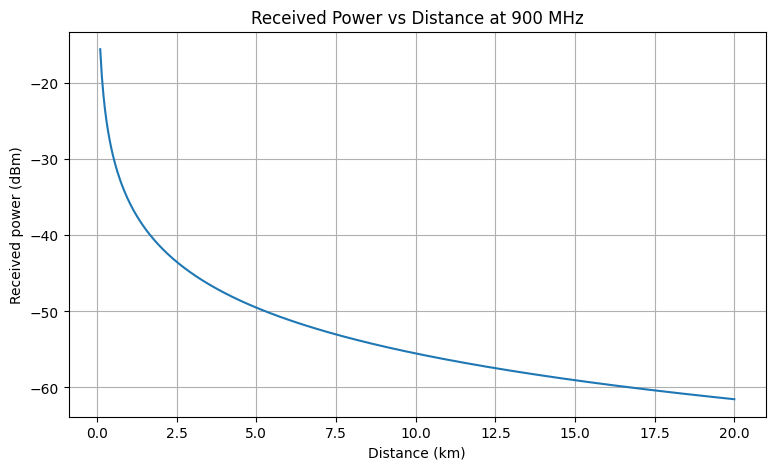

In [27]:
plt.figure(figsize=(9, 5))
plt.plot(distance_km, received_power_dbm)
plt.xlabel("Distance (km)")
plt.ylabel("Received power (dBm)")
plt.title(f"Received Power vs Distance at {frequency_mhz:.0f} MHz")
plt.grid(True)
plt.show()

**Observation:** Received power decreases as free-space path loss increases. Antenna gain raises the link budget, while additional losses reduce it.

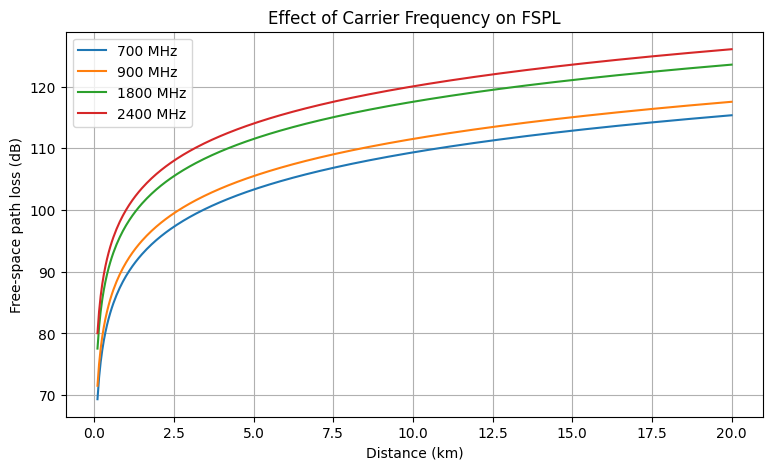

In [28]:
frequencies_mhz = [700, 900, 1800, 2400]

plt.figure(figsize=(9, 5))
for f_mhz in frequencies_mhz:
    plt.plot(distance_km, fspl_db(distance_km, f_mhz), label=f"{f_mhz} MHz")

plt.xlabel("Distance (km)")
plt.ylabel("Free-space path loss (dB)")
plt.title("Effect of Carrier Frequency on FSPL")
plt.legend()
plt.grid(True)
plt.show()

**Observation:** At the same distance, a higher carrier frequency has higher free-space path loss.

## Result and Discussion

The notebook verifies the expected free-space trends: path loss increases with both distance and frequency, while received power decreases as total link loss rises.

## Conclusion

Free-space path loss and received power were calculated and visualized successfully using Python as the implementation platform.

## Viva Questions and Short Answers

1. **When is the free-space model appropriate?**  
   For ideal unobstructed line-of-sight propagation.

2. **What happens to FSPL when distance increases by 10 times?**  
   It increases by 20 dB.

3. **What happens to FSPL when frequency increases?**  
   FSPL increases.

4. **What is the role of antenna gain in the link budget?**  
   Antenna gain increases the received power relative to an isotropic reference.

5. **Why must zero distance be avoided in the logarithmic formula?**  
   Because $\log_{10}(0)$ is undefined.

---

<a id="exp08"></a>

# Experiment 08: Analysis of Cell Coverage, Cell Radius, and Cell Splitting

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 4 cell coverage; Chapter 6 coverage improvement and cell splitting; Master Study Notes power-radius derivation.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To analyze cellular coverage area, cell radius, and the effect of cell splitting on area, transmitter power, and capacity.

## Objectives

- Relate cell radius to coverage area.
- Compare circular and hexagonal coverage approximations.
- Study cell splitting by reducing the cell radius.
- Apply the course power-radius relationship for a mobile-radio environment.
- Visualize the area reduction caused by splitting.

## Theory

**Cell coverage** is the geographic area in which a mobile can receive usable cellular service. The course notes list distance, obstacles/terrain, base-station power, and frequency as important factors that affect coverage.

### Coverage area

A convenient circular approximation is

$$
A_{\text{circle}}=\pi R^2
$$

For a regular hexagonal cell with center-to-vertex radius $R$,

$$
A_{\text{hex}}
=
\frac{3\sqrt{3}}{2}R^2
$$

### Cell splitting

Cell splitting replaces a congested large cell by smaller cells. If the new radius is

$$
R_2=\frac{R_1}{m}
$$

then area scales as $R^2$:

$$
\frac{A_2}{A_1}
=
\left(\frac{R_2}{R_1}\right)^2
=
\frac{1}{m^2}
$$

The course coverage derivation uses an approximate received-power behavior

$$
P_r=\alpha P_t R^{-4}
$$

in the considered mobile-radio region. If the receiver threshold is unchanged,

$$
\frac{R_2}{R_1}
=
\left(\frac{P_{t2}}{P_{t1}}\right)^{1/4}
$$

so

$$
\frac{P_{t2}}{P_{t1}}
=
\left(\frac{R_2}{R_1}\right)^4
$$

Therefore, halving the radius gives

$$
\frac{P_{t2}}{P_{t1}}
=
\left(\frac{1}{2}\right)^4
=
\frac{1}{16}
$$

for the $R^{-4}$ course model. More generally, for a path-loss exponent $n$,

$$
\frac{P_{t2}}{P_{t1}}=\left(\frac{R_2}{R_1}\right)^n
$$

and the code below uses this general form with $n=4$.

In [29]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon

# Configurable parameters
original_radius_km = 2.0
split_factor = 2.0
path_loss_exponent = 4.0

split_radius_km = original_radius_km / split_factor

def circular_area(radius_km):
    return np.pi * radius_km**2

def hexagonal_area(radius_km):
    return (3 * np.sqrt(3) / 2) * radius_km**2

original_circle_area = circular_area(original_radius_km)
split_circle_area = circular_area(split_radius_km)

original_hex_area = hexagonal_area(original_radius_km)
split_hex_area = hexagonal_area(split_radius_km)

power_ratio = (split_radius_km / original_radius_km)**path_loss_exponent
power_change_db = 10 * np.log10(power_ratio)

results = pd.DataFrame({
    "Quantity": [
        "Original radius (km)",
        "Split radius (km)",
        "Original circular area (km²)",
        "Split circular area (km²)",
        "Original hexagonal area (km²)",
        "Split hexagonal area (km²)",
        "Pt_new / Pt_old",
        "Power change (dB)"
    ],
    "Value": [
        original_radius_km,
        split_radius_km,
        original_circle_area,
        split_circle_area,
        original_hex_area,
        split_hex_area,
        power_ratio,
        power_change_db
    ]
})

results

,Quantity,Value
0,Original radius (km),2.000000
1,Split radius (km),1.000000
2,Original circular area (km²),12.566371
3,Split circular area (km²),3.141593
4,Original hexagonal area (km²),10.392305
5,Split hexagonal area (km²),2.598076
6,Pt_new / Pt_old,0.062500
7,Power change (dB),-12.041200


### Interpretation of the Example

With $R_2=R_1/2$:

$$
\frac{A_2}{A_1}=\left(\frac12\right)^2=\frac14
$$

Each split cell therefore covers one quarter of the original area. Approximately four cells of this new scale are needed to cover the same idealized total area.

For the course $R^{-4}$ model:

$$
\frac{P_{t2}}{P_{t1}}=\frac{1}{16}
$$

which is approximately

$$
10\log_{10}\left(\frac1{16}\right)\approx -12.04\text{ dB}
$$

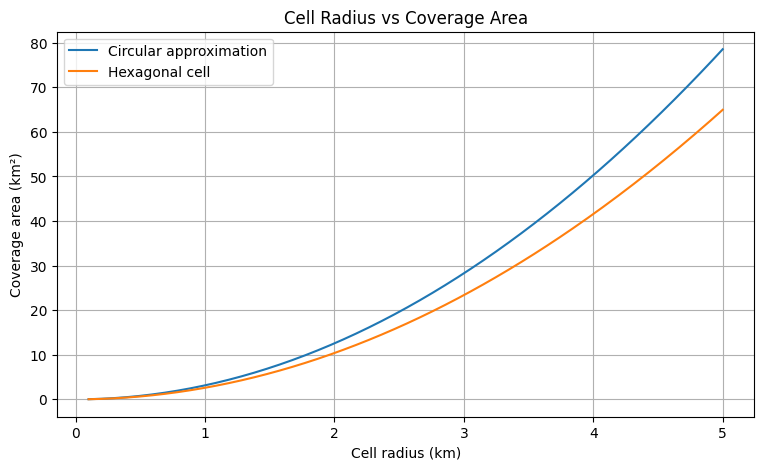

In [30]:
radii_km = np.linspace(0.1, 5.0, 250)
areas_circle = circular_area(radii_km)
areas_hex = hexagonal_area(radii_km)

plt.figure(figsize=(9, 5))
plt.plot(radii_km, areas_circle, label="Circular approximation")
plt.plot(radii_km, areas_hex, label="Hexagonal cell")
plt.xlabel("Cell radius (km)")
plt.ylabel("Coverage area (km²)")
plt.title("Cell Radius vs Coverage Area")
plt.legend()
plt.grid(True)
plt.show()

**Observation:** Coverage area grows with the square of radius, so even a moderate change in radius produces a large change in area.

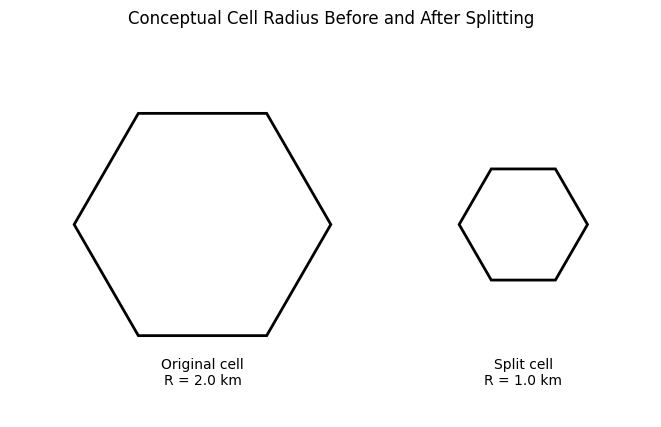

In [31]:
plt.figure(figsize=(9, 5))
ax = plt.gca()

original_hex = RegularPolygon(
    (0, 0), numVertices=6, radius=original_radius_km,
    orientation=np.pi/6, fill=False, linewidth=2
)
split_hex = RegularPolygon(
    (5, 0), numVertices=6, radius=split_radius_km,
    orientation=np.pi/6, fill=False, linewidth=2
)

ax.add_patch(original_hex)
ax.add_patch(split_hex)

plt.text(0, -2.5, f"Original cell\nR = {original_radius_km:.1f} km", ha="center")
plt.text(5, -2.5, f"Split cell\nR = {split_radius_km:.1f} km", ha="center")

plt.xlim(-3, 7)
plt.ylim(-3, 3)
plt.gca().set_aspect("equal", adjustable="box")
plt.axis("off")
plt.title("Conceptual Cell Radius Before and After Splitting")
plt.show()

## Result and Discussion

Halving cell radius reduces each idealized cell area to one quarter. Under the course $R^{-4}$ power model, the transmitter power required for the smaller cell is one sixteenth of the original value if the receive threshold remains unchanged.

Cell splitting increases capacity because the available frequency plan can be reused over a denser set of smaller cells, but it also requires more base-station infrastructure and more mobility/handover management.

## Conclusion

Cell coverage, radius, and splitting relationships were analyzed successfully. The notebook verifies the square-law area scaling and the course power-radius relationship.

## Viva Questions and Short Answers

1. **What is cell coverage?**  
   The geographic region where usable cellular service is available.

2. **How does area scale with radius?**  
   Area is proportional to $R^2$.

3. **What is cell splitting?**  
   Dividing a congested large cell into smaller cells to increase local capacity.

4. **If radius is halved, what happens to idealized cell area?**  
   It becomes one quarter.

5. **For the $R^{-4}$ model, what transmit-power ratio is needed when radius is halved?**  
   $P_{t2}/P_{t1}=1/16$.

---

<a id="exp09"></a>

# Experiment 09: Cellular Traffic, Channel Capacity, and Erlang-B Blocking Probability Analysis

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Course Master Study Notes (offered-load and calls/hour formulas) and William C. Y. Lee reference text / Erlang-B tables and blocking discussion.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To analyze cellular traffic load, channel capacity, Grade of Service, and Erlang-B blocking probability.

## Objectives

- Calculate offered traffic in Erlangs.
- Relate calls per hour and holding time to traffic load.
- Calculate call-blocking probability with Erlang B.
- Determine the minimum number of channels for a target Grade of Service.
- Visualize how traffic and channel capacity affect blocking.

## Theory

### Offered traffic

One **Erlang** represents one channel occupied continuously for one hour.

If $Q$ calls are offered per hour and the mean holding time is $T$ minutes,

$$
A=\frac{QT}{60}
$$

If holding time is in seconds,

$$
A=\frac{Q T_s}{3600}
$$

Conversely,

$$
Q=\frac{3600A}{T_s}
$$

The course notes repeatedly use this relationship for cellular traffic calculations.

### Blocking probability and Grade of Service

In a blocked-calls-cleared system, a new call is blocked when all channels are occupied. The **Erlang-B** probability for offered traffic $A$ and $N$ channels can be calculated stably by recursion:

$$
B_0=1
$$

$$
B_n=\frac{A B_{n-1}}{n+A B_{n-1}},
\qquad n=1,2,\dots,N
$$

Then $B_N$ is the final blocking probability.

A common Grade of Service target in the course/reference examples is approximately

$$
B=0.02=2\%
$$

during the busy hour.

The carried traffic can be estimated as

$$
A_c=A(1-B)
$$

and blocked traffic as

$$
A_b=AB
$$

In [32]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def erlang_b(offered_traffic, channels):
    B = 1.0
    for n in range(1, channels + 1):
        B = (offered_traffic * B) / (n + offered_traffic * B)
    return B

# Course-style example
offered_traffic_erlangs = 78.3
channels = 90

blocking_probability = erlang_b(offered_traffic_erlangs, channels)
carried_traffic = offered_traffic_erlangs * (1 - blocking_probability)
blocked_traffic = offered_traffic_erlangs * blocking_probability

print(f"Offered traffic       : {offered_traffic_erlangs:.2f} Erlangs")
print(f"Number of channels    : {channels}")
print(f"Blocking probability  : {blocking_probability:.6f}")
print(f"Blocking percentage   : {100*blocking_probability:.3f}%")
print(f"Carried traffic       : {carried_traffic:.3f} Erlangs")
print(f"Blocked traffic       : {blocked_traffic:.3f} Erlangs")

Offered traffic       : 78.30 Erlangs
Number of channels    : 90
Blocking probability  : 0.019980
Blocking percentage   : 1.998%
Carried traffic       : 76.736 Erlangs
Blocked traffic       : 1.564 Erlangs


### Validation Example

For

$$
A=78.3\text{ Erlangs},\qquad N=90
$$

the recursive implementation gives approximately

$$
B\approx0.01998\approx2.0\%
$$

which matches the intended 2% busy-hour blocking level very closely.

In [33]:
# Calls/hour relation used in the course notes
mean_holding_time_s = 100.0
calls_per_hour = 3600 * offered_traffic_erlangs / mean_holding_time_s

print(f"With A = {offered_traffic_erlangs:.1f} Erlangs")
print(f"and mean holding time = {mean_holding_time_s:.0f} s,")
print(f"calls per hour = {calls_per_hour:.1f} ≈ {round(calls_per_hour)} calls/hour")

With A = 78.3 Erlangs
and mean holding time = 100 s,
calls per hour = 2818.8 ≈ 2819 calls/hour


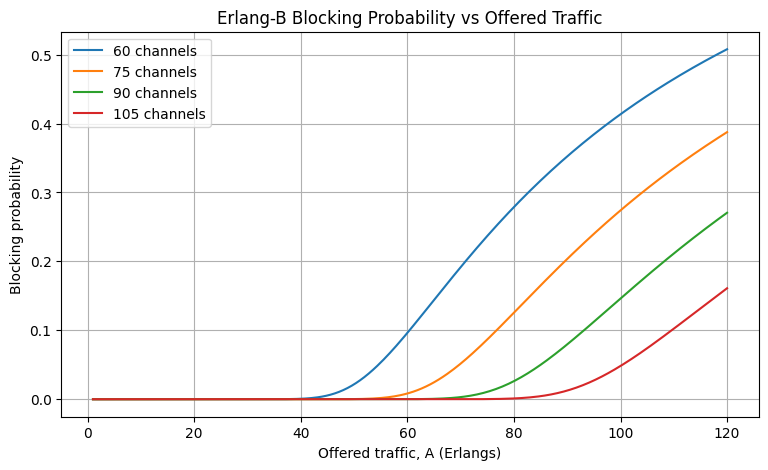

In [34]:
traffic_range = np.linspace(1, 120, 300)
channel_sets = [60, 75, 90, 105]

plt.figure(figsize=(9, 5))
for n_channels in channel_sets:
    blocking = [erlang_b(A, n_channels) for A in traffic_range]
    plt.plot(traffic_range, blocking, label=f"{n_channels} channels")

plt.xlabel("Offered traffic, A (Erlangs)")
plt.ylabel("Blocking probability")
plt.title("Erlang-B Blocking Probability vs Offered Traffic")
plt.legend()
plt.grid(True)
plt.show()

**Observation:** Blocking rises rapidly as offered traffic approaches and exceeds the practical carrying capability of a fixed number of channels. Adding channels shifts the blocking curve downward.

In [35]:
target_gos = 0.02

def minimum_channels_for_gos(offered_traffic, target_blocking, max_channels=500):
    for n_channels in range(1, max_channels + 1):
        if erlang_b(offered_traffic, n_channels) <= target_blocking:
            return n_channels
    return None

min_channels = minimum_channels_for_gos(
    offered_traffic_erlangs,
    target_gos
)

print(f"Minimum channels for A={offered_traffic_erlangs:.1f} Erlangs")
print(f"at GoS B <= {target_gos:.2%}: {min_channels}")

Minimum channels for A=78.3 Erlangs
at GoS B <= 2.00%: 90


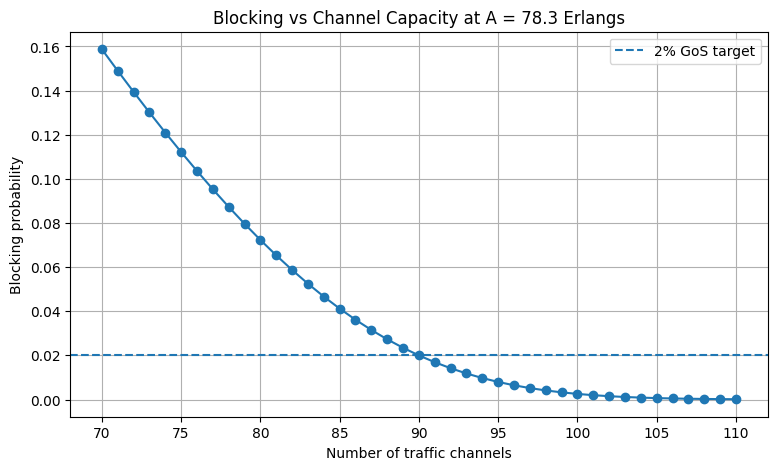

In [36]:
channel_range = np.arange(70, 111)
blocking_by_channels = np.array([
    erlang_b(offered_traffic_erlangs, n) for n in channel_range
])

plt.figure(figsize=(9, 5))
plt.plot(channel_range, blocking_by_channels, marker="o")
plt.axhline(target_gos, linestyle="--", label="2% GoS target")
plt.xlabel("Number of traffic channels")
plt.ylabel("Blocking probability")
plt.title(f"Blocking vs Channel Capacity at A = {offered_traffic_erlangs:.1f} Erlangs")
plt.legend()
plt.grid(True)
plt.show()

## Result and Discussion

For $A=78.3$ Erlangs and $N=90$ channels, Erlang-B blocking is approximately **2%**. The experiment also confirms that more traffic increases blocking while more channels reduce it.

The Erlang-B model assumes blocked calls are cleared rather than queued, so it is appropriate as a simple busy-hour voice-channel model.

## Conclusion

Offered load, calls per hour, channel capacity, and Erlang-B blocking probability were calculated successfully. The simulation also determines the channel count required to meet a target Grade of Service.

## Viva Questions and Short Answers

1. **What is one Erlang?**  
   One channel occupied continuously for one hour.

2. **What is Grade of Service in this experiment?**  
   The accepted call-blocking probability target.

3. **What does Erlang B assume happens to a blocked call?**  
   It is cleared/lost rather than waiting in a queue.

4. **What happens to blocking if offered traffic increases but channels remain fixed?**  
   Blocking probability increases.

5. **What happens to blocking if the number of channels increases for the same traffic?**  
   Blocking probability decreases.